In [136]:
from pathlib import Path

import pandas as pd
import numpy as np

# Localizar raíz del proyecto
ROOT = Path.cwd()

while not (ROOT / "src" / "database" / "TFM.duckdb").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError(
            "No se ha encontrado la raíz del proyecto."
        )
    ROOT = ROOT.parent

DATA_PATH = (
    ROOT
    / "data"
    / "modeling"
    / "dataset_mag14_t1.parquet"
)

df = pd.read_parquet(DATA_PATH)

print(f"Dataset cargado: {df.shape}")

Dataset cargado: (23556, 111)


# 0. EDA

In [137]:
VARIABLES_METEO = ['direccion_racha_max',
                    'humedad_max',
                    'humedad_media',
                    'humedad_min',
                    'precipitacion',
                    'presion_max',
                    'presion_min',
                    'temp_max',
                    'temp_media',
                    'temp_min',
                    'viento_racha',
                    'viento_velocidad']

In [138]:
df["target_mag_14"].describe()

count    23556.000000
mean        53.902590
std         23.585672
min          1.208333
25%         36.203274
50%         56.190833
75%         71.963003
max        124.833333
Name: target_mag_14, dtype: float64

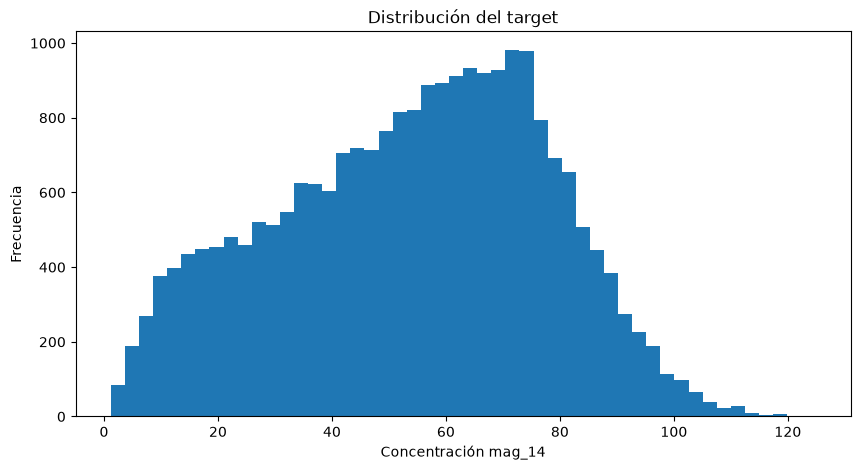

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["target_mag_14"],
    bins=50
)

plt.xlabel("Concentración mag_14")
plt.ylabel("Frecuencia")
plt.title("Distribución del target")

plt.show()

In [140]:
station_stats = (
    df.groupby("estacion")["target_mag_14"]
    .agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    .round(2)
)

display(station_stats)

,count,mean,std,min,median,max
estacion,,,,,,
8,1812,51.06,21.95,1.83,52.36,107.00
16,1812,53.73,23.68,2.24,55.67,115.33
17,1812,50.55,23.20,1.71,53.66,106.88
18,1812,52.86,24.12,1.73,56.02,112.08
24,1812,57.66,24.08,1.50,60.32,124.83
27,1812,51.33,23.32,1.21,55.02,110.83
35,1812,54.47,24.10,1.33,57.29,110.43
39,1812,54.03,24.24,2.12,55.14,121.42
49,1812,53.84,23.21,1.79,56.46,111.92


<Figure size 1200x500 with 0 Axes>

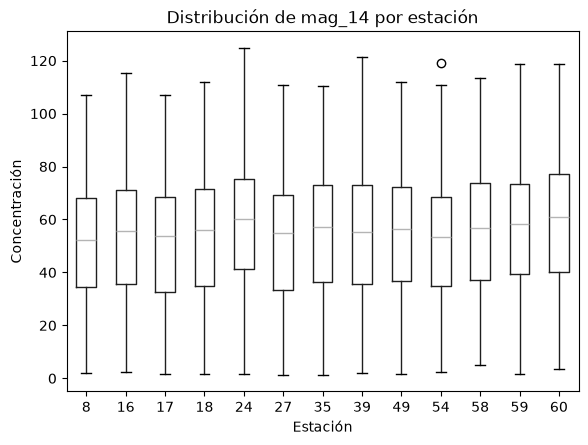

In [141]:
plt.figure(figsize=(12, 5))

df.boxplot(
    column="target_mag_14",
    by="estacion",
    grid=False
)

plt.title("Distribución de mag_14 por estación")
plt.suptitle("")
plt.xlabel("Estación")
plt.ylabel("Concentración")

plt.show()

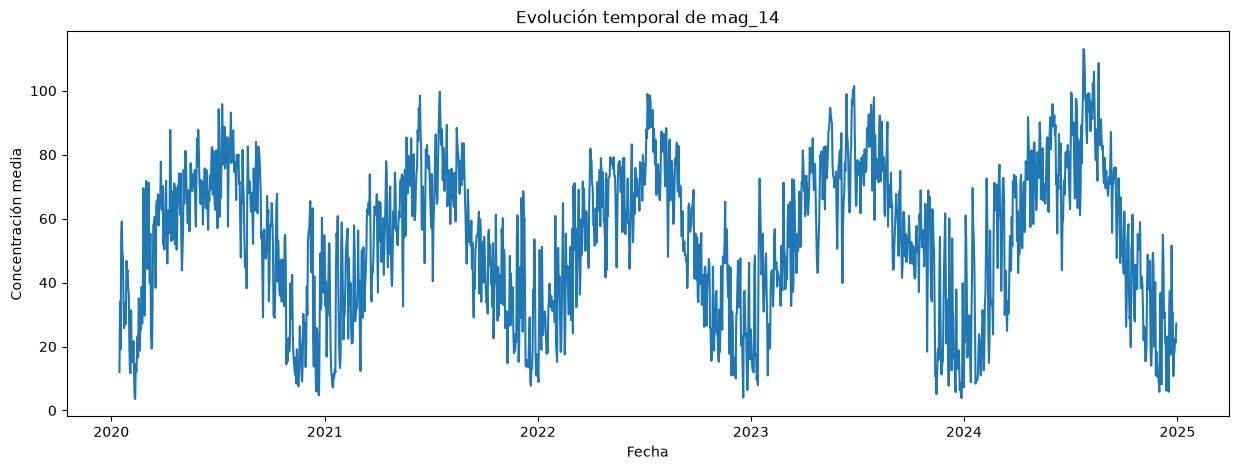

In [142]:
daily_target = (
    df.groupby("fecha")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_target.index,
    daily_target.values
)

plt.xlabel("Fecha")
plt.ylabel("Concentración media")
plt.title("Evolución temporal de mag_14")

plt.show()

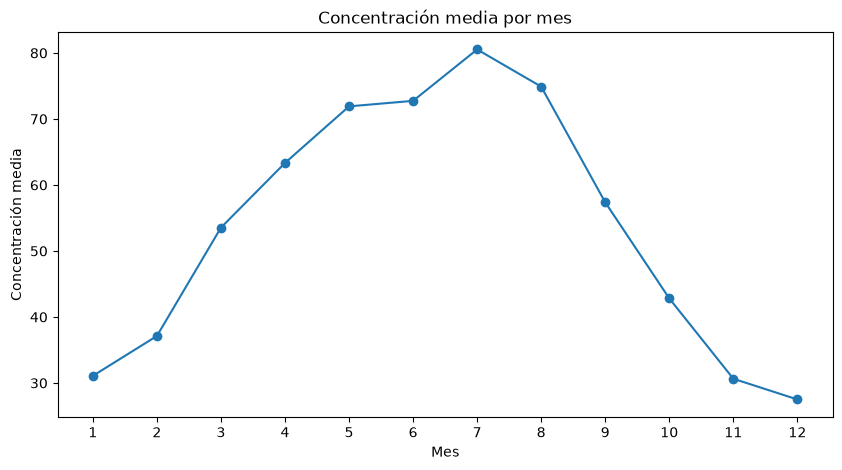

In [143]:
monthly = (
    df.groupby("month")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.xlabel("Mes")
plt.ylabel("Concentración media")
plt.title("Concentración media por mes")
plt.xticks(range(1, 13))

plt.show()

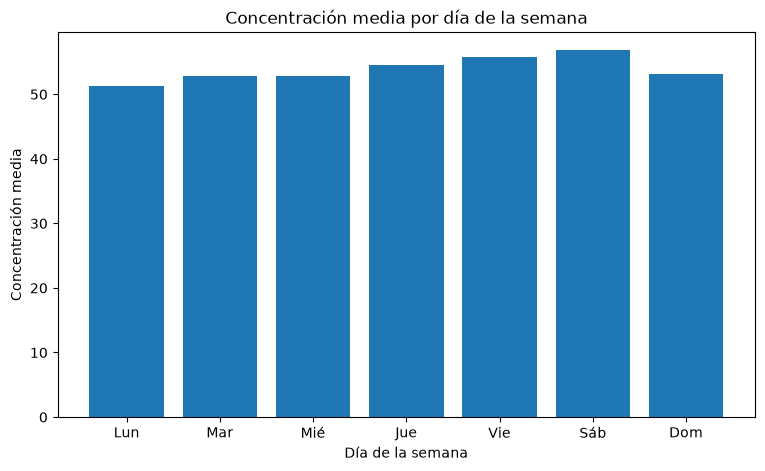

In [144]:
dow = (
    df.groupby("day_of_week")["target_mag_14"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.bar(
    dow.index,
    dow.values
)

plt.xlabel("Día de la semana")
plt.ylabel("Concentración media")
plt.title("Concentración media por día de la semana")
plt.xticks(range(7), [
    "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"
])

plt.show()

In [145]:
lag_corr = df[
    [
        "target_mag_14",
        "mag_14_lag_0",
        "mag_14_lag_1",
        "mag_14_lag_2",
        "mag_14_lag_3",
        "mag_14_lag_7",
        "mag_14_lag_14"
    ]
].corr()["target_mag_14"].sort_values(ascending=False)

display(lag_corr)

target_mag_14    1.000000
mag_14_lag_0     0.854171
mag_14_lag_1     0.765653
mag_14_lag_2     0.728557
mag_14_lag_3     0.698949
mag_14_lag_7     0.679674
mag_14_lag_14    0.624677
Name: target_mag_14, dtype: float64

In [146]:
current_meteo = [
    f"{col}_lag_0"
    for col in VARIABLES_METEO
    if f"{col}_lag_0" in df.columns
]

corr_meteo = (
    df[["target_mag_14"] + current_meteo]
    .corr()["target_mag_14"]
    .drop("target_mag_14")
    .sort_values()
)

display(corr_meteo)

humedad_media_lag_0         -0.610375
humedad_min_lag_0           -0.588259
humedad_max_lag_0           -0.549100
presion_max_lag_0           -0.392439
presion_min_lag_0           -0.372555
precipitacion_lag_0         -0.000105
direccion_racha_max_lag_0    0.025265
viento_velocidad_lag_0       0.284549
viento_racha_lag_0           0.393979
temp_min_lag_0               0.616915
temp_media_lag_0             0.655455
temp_max_lag_0               0.659511
Name: target_mag_14, dtype: float64

# 1. Separación del dataset

In [147]:
df = df.sort_values(
    ["fecha", "estacion"]
).reset_index(drop=True)

train = df[
    df["fecha"] < "2023-01-01"
].copy()

val = df[
    (df["fecha"] >= "2023-01-01") &
    (df["fecha"] < "2024-01-01")
].copy()

test = df[
    df["fecha"] >= "2024-01-01"
].copy()

print(
    f"Train: {train['fecha'].min().date()} "
    f"→ {train['fecha'].max().date()} "
    f"({len(train):,} filas)"
)

print(
    f"Val:   {val['fecha'].min().date()} "
    f"→ {val['fecha'].max().date()} "
    f"({len(val):,} filas)"
)

print(
    f"Test:  {test['fecha'].min().date()} "
    f"→ {test['fecha'].max().date()} "
    f"({len(test):,} filas)"
)

Train: 2020-01-15 → 2022-12-31 (14,066 filas)
Val:   2023-01-01 → 2023-12-31 (4,745 filas)
Test:  2024-01-01 → 2024-12-30 (4,745 filas)


# 2. Modelado

## 2.1. Modelo simple: concentracion de mañana será igual a la de hoy

In [148]:
val["pred_persistence"] = val["mag_14_lag_0"]

In [149]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_persistence_val = mean_absolute_error(
    val["target_mag_14"],
    val["pred_persistence"]
)

rmse_persistence_val = np.sqrt(
    mean_squared_error(
        val["target_mag_14"],
        val["pred_persistence"]
    )
)

r2_persistence_val = r2_score(
    val["target_mag_14"],
    val["pred_persistence"]
)

print(f"MAE : {mae_persistence_val:.3f}")
print(f"RMSE: {rmse_persistence_val:.3f}")
print(f"R²  : {r2_persistence_val:.3f}")

MAE : 9.425
RMSE: 12.729
R²  : 0.706


In [150]:
results = []

results.append({
    "model": "Persistencia",
    "split": "validation",
    "MAE": mae_persistence_val,
    "RMSE": rmse_persistence_val,
    "R2": r2_persistence_val
})

results

[{'model': 'Persistencia',
  'split': 'validation',
  'MAE': 9.425450705359998,
  'RMSE': np.float64(12.729351199240435),
  'R2': 0.7059826234624222}]

In [151]:
persistence_by_station = (
    val.groupby("estacion")
    .apply(
        lambda g: pd.Series({
            "MAE": mean_absolute_error(
                g["target_mag_14"],
                g["pred_persistence"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    g["target_mag_14"],
                    g["pred_persistence"]
                )
            ),
            "R2": r2_score(
                g["target_mag_14"],
                g["pred_persistence"]
            )
        }),
        include_groups=False
    )
    .round(3)
)

print(persistence_by_station)

             MAE    RMSE     R2
estacion                       
8          8.435  11.437  0.721
16         9.387  12.476  0.730
17         9.682  12.820  0.682
18         9.662  13.056  0.708
24         9.260  12.890  0.686
27         9.779  13.053  0.685
35         8.922  12.017  0.758
39         9.546  13.054  0.719
49         9.716  13.248  0.659
54         9.355  12.340  0.663
58         9.512  12.997  0.695
59        10.047  13.441  0.700
60         9.228  12.511  0.699


## 2.2. Regresión lineal múltiple

In [152]:
target_col = "target_mag_14"

feature_cols = [
    c for c in df.columns
    if c not in [
        "fecha",
        "target_mag_14",
        "estacion"
    ]
]

X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

print("Features:", len(feature_cols))
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

Features: 108
X_train: (14066, 108)
X_val: (4745, 108)


Regresión multiple no acepta NaN

In [153]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

Escalamos las variables

In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imp
)

X_val_scaled = scaler.transform(
    X_val_imp
)

Entrenamos

In [155]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](108,)","[-0.76, 0.77,-0.55,..., 0.52,-5.04,-0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,52.21
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,108
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(107)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](108,)","[738.18,407.29,298.49,..., 0.41, 0.39, 0. ]"


Predecimos

In [156]:
pred_lr = lr.predict(
    X_val_scaled
)

Evaluamos

In [157]:
mae_lr = mean_absolute_error(
    y_val,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_val,
        pred_lr
    )
)

r2_lr = r2_score(
    y_val,
    pred_lr
)

print(f"MAE : {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²  : {r2_lr:.3f}")

MAE : 8.910
RMSE: 11.451
R²  : 0.762


In [158]:
results.append({
    "model": "Regresión lineal múltiple",
    "split": "validation",
    "MAE": mae_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
})

print(results)

[{'model': 'Persistencia', 'split': 'validation', 'MAE': 9.425450705359998, 'RMSE': np.float64(12.729351199240435), 'R2': 0.7059826234624222}, {'model': 'Regresión lineal múltiple', 'split': 'validation', 'MAE': 8.90986712690434, 'RMSE': np.float64(11.451034851626167), 'R2': 0.762069600595781}]


## 2.3. XGBoost

In [159]:
import xgboost as xgb

print("XGBoost:", xgb.__version__)

XGBoost: 3.4.1


In [160]:
target_col = "target_mag_14"

feature_cols_xgb = [
    c for c in df.columns
    if c not in [
        "fecha",
        "target_mag_14",
        "estacion"
    ]
]

X_train = train[feature_cols_xgb]
y_train = train[target_col]

X_val = val[feature_cols_xgb]
y_val = val[target_col]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Número de features:", len(feature_cols_xgb))

X_train: (14066, 108)
X_val: (4745, 108)
Número de features: 108


In [161]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [162]:
pred_xgb = xgb_model.predict(X_val)

In [163]:
mae_xgb = mean_absolute_error(
    y_val,
    pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_val,
        pred_xgb
    )
)

r2_xgb = r2_score(
    y_val,
    pred_xgb
)

print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

MAE : 8.639
RMSE: 10.981
R²  : 0.781


In [164]:
results.append({
    "model": "XGBoost base",
    "split": "validation",
    "MAE": mae_xgb,
    "RMSE": rmse_xgb,
    "R2": r2_xgb
})

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset=["model", "split"]
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df.round(3))

,model,split,MAE,RMSE,R2
0,XGBoost base,validation,8.639,10.981,0.781
1,Regresión lineal múltiple,validation,8.910,11.451,0.762
2,Persistencia,validation,9.425,12.729,0.706


In [165]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_cols_xgb,
        "importance": xgb_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20))

                feature  importance
0          mag_14_lag_0    0.139830
1         mag_14_mean_7    0.139036
2         mag_14_mean_3    0.120533
3        mag_14_mean_14    0.104362
4    viento_racha_lag_0    0.024775
5               doy_cos    0.022286
6   precipitacion_lag_0    0.017363
7           day_of_year    0.013838
8               dow_cos    0.012057
9           day_of_week    0.011601
10    presion_max_lag_0    0.008728
11              dow_sin    0.008548
12              doy_sin    0.008353
13  precipitacion_lag_1    0.008281
14       temp_max_lag_3    0.007838
15  humedad_media_lag_6    0.007710
16       temp_max_lag_6    0.007652
17  precipitacion_lag_5    0.007018
18    presion_min_lag_0    0.006819
19  precipitacion_lag_4    0.006221


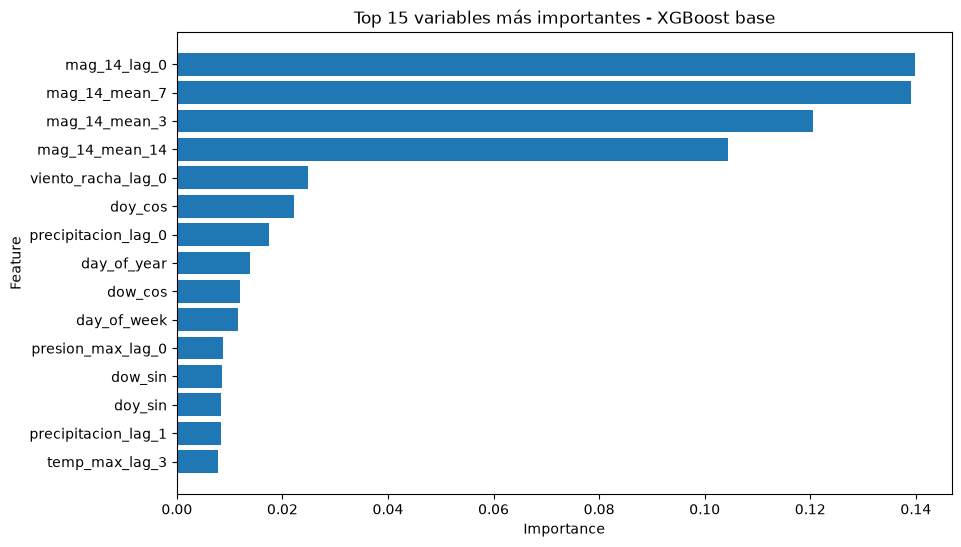

In [166]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 variables más importantes - XGBoost base")

plt.show()

Estudio por estación

In [167]:
val["pred_xgb"] = pred_xgb

xgb_by_station = (
    val.groupby("estacion")
    .apply(
        lambda g: pd.Series({
            "MAE": mean_absolute_error(
                g["target_mag_14"],
                g["pred_xgb"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    g["target_mag_14"],
                    g["pred_xgb"]
                )
            ),
            "R2": r2_score(
                g["target_mag_14"],
                g["pred_xgb"]
            )
        }),
        include_groups=False
    )
    .round(3)
)

print(xgb_by_station)

            MAE    RMSE     R2
estacion                      
8         7.819  10.078  0.784
16        8.565  10.821  0.797
17        8.669  10.957  0.768
18        8.887  11.214  0.784
24        8.827  11.216  0.762
27        8.701  10.756  0.786
35        8.135  10.471  0.816
39        8.767  11.202  0.793
49        8.819  11.204  0.756
54        8.348  10.623  0.750
58        9.073  11.503  0.761
59        9.178  11.618  0.776
60        8.513  10.986  0.768


Ahora hacemos fine tunning al modelo a ver si podemos mejorarlo

In [168]:
import numpy as np

unique_dates = np.sort(
    train["fecha"].unique()
)

n_splits = 3

folds = []

for i in range(1, n_splits + 1):
    
    split_1 = int(
        len(unique_dates) * i / (n_splits + 1)
    )
    
    split_2 = int(
        len(unique_dates) * (i + 1) / (n_splits + 1)
    )
    
    train_dates = unique_dates[:split_1]
    val_dates = unique_dates[split_1:split_2]
    
    train_idx = train.index[
        train["fecha"].isin(train_dates)
    ]
    
    val_idx = train.index[
        train["fecha"].isin(val_dates)
    ]
    
    folds.append(
        (
            train_idx.to_numpy(),
            val_idx.to_numpy()
        )
    )
    
    print(
        f"Fold {i}: "
        f"{train_dates[0]} → {train_dates[-1]} | "
        f"{val_dates[0]} → {val_dates[-1]}"
    )

Fold 1: 2020-01-15T00:00:00.000000 → 2020-10-10T00:00:00.000000 | 2020-10-11T00:00:00.000000 → 2021-07-08T00:00:00.000000
Fold 2: 2020-01-15T00:00:00.000000 → 2021-07-08T00:00:00.000000 | 2021-07-09T00:00:00.000000 → 2022-04-04T00:00:00.000000
Fold 3: 2020-01-15T00:00:00.000000 → 2022-04-04T00:00:00.000000 | 2022-04-05T00:00:00.000000 → 2022-12-31T00:00:00.000000


In [169]:
param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

In [170]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=folds,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [171]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ...shape=(3510,)), ...), (array([ 0, ...shape=(7033,)), ...), ...]"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_inde

In [172]:
print("Mejores parámetros:")
print(grid_search.best_params_)

print(
    f"\nMejor RMSE CV: "
    f"{-grid_search.best_score_:.3f}"
)

Mejores parámetros:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.8}

Mejor RMSE CV: 11.634


In [173]:
cv_results = (
    pd.DataFrame(
        grid_search.cv_results_
    )
    .sort_values(
        "rank_test_score"
    )
)

display(
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_n_estimators",
            "param_learning_rate",
            "param_max_depth",
            "param_min_child_weight",
            "param_subsample",
            "param_colsample_bytree"
        ]
    ].head(10)
)

,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree
7,1,-11.634032,1.079929,500,0.05,5,5,0.8,0.8
2,2,-11.643936,1.139237,300,0.05,3,5,0.8,0.8
6,3,-11.644079,1.095099,300,0.05,5,5,0.8,0.8
5,4,-11.653986,1.133351,500,0.05,5,1,0.8,0.8
4,5,-11.661898,1.116125,300,0.05,5,1,0.8,0.8
0,6,-11.662560,1.196095,300,0.05,3,1,0.8,0.8
3,7,-11.663137,1.092954,500,0.05,3,5,0.8,0.8
14,8,-11.674694,1.103925,300,0.10,3,5,0.8,0.8
16,9,-11.690907,1.073185,300,0.10,5,1,0.8,0.8
1,10,-11.700437,1.196666,500,0.05,3,1,0.8,0.8


In [174]:
best_xgb = grid_search.best_estimator_

pred_xgb_tuned = best_xgb.predict(
    X_val
)

In [175]:
mae_xgb_tuned = mean_absolute_error(
    y_val,
    pred_xgb_tuned
)

rmse_xgb_tuned = np.sqrt(
    mean_squared_error(
        y_val,
        pred_xgb_tuned
    )
)

r2_xgb_tuned = r2_score(
    y_val,
    pred_xgb_tuned
)

print(f"MAE : {mae_xgb_tuned:.3f}")
print(f"RMSE: {rmse_xgb_tuned:.3f}")
print(f"R²  : {r2_xgb_tuned:.3f}")

MAE : 8.627
RMSE: 10.987
R²  : 0.781


In [176]:
results.append({
    "model": "XGBoost tuned",
    "split": "validation",
    "MAE": mae_xgb_tuned,
    "RMSE": rmse_xgb_tuned,
    "R2": r2_xgb_tuned
})

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset=["model", "split"]
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(results_df.round(3))

                       model       split    MAE    RMSE     R2
0               XGBoost base  validation  8.639  10.981  0.781
1              XGBoost tuned  validation  8.627  10.987  0.781
2  Regresión lineal múltiple  validation  8.910  11.451  0.762
3               Persistencia  validation  9.425  12.729  0.706


## 2.4. XGBoost meteo

In [177]:
temporal_cols = [
    "day_of_week",
    "month",
    "day_of_year",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "es_laborable_madrid_ciudad",
]

meteo_feature_cols = [
    c for c in df.columns
    if "_lag_" in c
    and not c.startswith("mag_")
]

feature_cols_xgb_meteo = (
    meteo_feature_cols
    + temporal_cols
)

print("Variables meteorológicas:", len(meteo_feature_cols))
print("Variables temporales:", len(temporal_cols))
print("Total features:", len(feature_cols_xgb_meteo))

Variables meteorológicas: 84
Variables temporales: 8
Total features: 92


In [178]:
X_train_meteo = train[
    feature_cols_xgb_meteo
]

y_train_meteo = train[
    target_col
]

X_val_meteo = val[
    feature_cols_xgb_meteo
]

y_val_meteo = val[
    target_col
]

print("X_train:", X_train_meteo.shape)
print("X_val:", X_val_meteo.shape)

X_train: (14066, 92)
X_val: (4745, 92)


In [179]:
xgb_meteo = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_meteo.fit(
    X_train_meteo,
    y_train_meteo
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [180]:
pred_xgb_meteo = xgb_meteo.predict(
    X_val_meteo
)

In [181]:
feature_importance_meteo = (
    pd.DataFrame({
        "feature": feature_cols_xgb_meteo,
        "importance": xgb_meteo.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(
    feature_importance_meteo.head(25)
)

,feature,importance
0,doy_cos,0.385708
1,viento_racha_lag_0,0.074200
2,temp_max_lag_0,0.065151
3,day_of_year,0.028440
4,doy_sin,0.022021
5,month,0.019729
6,temp_max_lag_3,0.019055
7,precipitacion_lag_0,0.017207
8,temp_media_lag_1,0.011545
9,day_of_week,0.011427


In [182]:
mae_xgb_meteo = mean_absolute_error(
    y_val_meteo,
    pred_xgb_meteo
)

rmse_xgb_meteo = np.sqrt(
    mean_squared_error(
        y_val_meteo,
        pred_xgb_meteo
    )
)

r2_xgb_meteo = r2_score(
    y_val_meteo,
    pred_xgb_meteo
)

print(f"MAE : {mae_xgb_meteo:.3f}")
print(f"RMSE: {rmse_xgb_meteo:.3f}")
print(f"R²  : {r2_xgb_meteo:.3f}")

MAE : 10.587
RMSE: 13.101
R²  : 0.689


In [183]:
results.append({
    "model": "XGBoost solo meteo",
    "split": "validation",
    "MAE": mae_xgb_meteo,
    "RMSE": rmse_xgb_meteo,
    "R2": r2_xgb_meteo
})

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset=["model", "split"]
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(results_df.round(3))

                       model       split     MAE    RMSE     R2
0               XGBoost base  validation   8.639  10.981  0.781
1              XGBoost tuned  validation   8.627  10.987  0.781
2  Regresión lineal múltiple  validation   8.910  11.451  0.762
3               Persistencia  validation   9.425  12.729  0.706
4         XGBoost solo meteo  validation  10.587  13.101  0.689


## 2.5. XGBoost Meteo

In [184]:
contaminacion_feature_cols = [
    c for c in df.columns
    if c.startswith("mag_")
    and c != "target_mag_14"
]

feature_cols_xgb_contaminacion = (
    contaminacion_feature_cols
    + temporal_cols
)

print("Features contaminación:", len(contaminacion_feature_cols))
print("Features calendario:", len(temporal_cols))
print("Total:", len(feature_cols_xgb_contaminacion))

Features contaminación: 16
Features calendario: 8
Total: 24


In [185]:
X_train_cont = train[
    feature_cols_xgb_contaminacion
]

y_train_cont = train[
    target_col
]

X_val_cont = val[
    feature_cols_xgb_contaminacion
]

y_val_cont = val[
    target_col
]

print("X_train:", X_train_cont.shape)
print("X_val:", X_val_cont.shape)

X_train: (14066, 24)
X_val: (4745, 24)


In [186]:
xgb_contaminacion = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_contaminacion.fit(
    X_train_cont,
    y_train_cont
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [187]:
pred_xgb_contaminacion = (
    xgb_contaminacion.predict(X_val_cont)
)

mae_xgb_cont = mean_absolute_error(
    y_val_cont,
    pred_xgb_contaminacion
)

rmse_xgb_cont = np.sqrt(
    mean_squared_error(
        y_val_cont,
        pred_xgb_contaminacion
    )
)

r2_xgb_cont = r2_score(
    y_val_cont,
    pred_xgb_contaminacion
)

print(f"MAE : {mae_xgb_cont:.3f}")
print(f"RMSE: {rmse_xgb_cont:.3f}")
print(f"R²  : {r2_xgb_cont:.3f}")

MAE : 9.684
RMSE: 12.396
R²  : 0.721


In [188]:
results.append({
    "model": "XGBoost solo contaminación",
    "split": "validation",
    "MAE": mae_xgb_cont,
    "RMSE": rmse_xgb_cont,
    "R2": r2_xgb_cont
})

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(
        subset=["model", "split"]
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(results_df.round(3))

                        model       split     MAE    RMSE     R2
0                XGBoost base  validation   8.639  10.981  0.781
1               XGBoost tuned  validation   8.627  10.987  0.781
2   Regresión lineal múltiple  validation   8.910  11.451  0.762
3  XGBoost solo contaminación  validation   9.684  12.396  0.721
4                Persistencia  validation   9.425  12.729  0.706
5          XGBoost solo meteo  validation  10.587  13.101  0.689


# 3. Estudio Modelo Ganador